# Modelo de Gradient Boosting

In [1]:
import os
import sys

os.chdir('..')
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

import mlflow

from src.models.utils import (
    init_mlflow, cargar_datos, get_cv_folds,
    evaluar_modelo, log_experimento
)

## 1. Carga de datos

In [2]:
X, y = cargar_datos()
cv = get_cv_folds()  # StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for i, (train_index, test_index) in enumerate(cv.split(X, y)):
    print(f"Fold {i}:")
    print(f"  Test:  index={test_index}")

Fold 0:
  Test:  index=[  1   9  10  13  14  21  33  34  41  45  52  53  61  68  74  78  87  93
  94  95  99 100 104 106 111 113 116 117 118 122 124 127 128 131 132 133
 134 136 137 141 148 153 156 157 159 160 169 177 196 198 206 208 221 227
 230 231 233 240 243 244 248 250 253 254 257 260 261 265 268 272 273 275
 276 278 301 312 314 328 332 337 342 353 357 374 378 411 418 432 438 440
 442 449 450 451 458 459 468 479 484 492 496 498 499 505 506 519 524 527
 529 531 534 541 567 572 576 579 585 586 588 591 594 596 606 610 616 630
 633 649 652 659 660 661 664]
Fold 1:
  Test:  index=[  5  11  12  25  28  30  32  35  44  46  47  49  58  77  85  89  91  96
 102 114 121 125 140 143 144 146 147 158 175 178 179 180 181 182 185 205
 212 215 216 217 220 222 224 239 241 249 262 263 274 279 281 284 286 287
 290 291 299 303 306 307 317 319 329 333 339 344 346 348 351 354 362 364
 365 375 379 381 382 383 395 396 401 407 409 410 412 415 417 419 426 433
 436 439 444 447 448 452 453 456 466 471 487 488

## 2. Configuracion de experimento

In [3]:
init_mlflow()
mlflow.set_experiment('gradientBoosting')

def make_pipeline(learning_rate=0.1, n_estimators=100, subsample=1.0, 
                  min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, 
                  max_depth=3, min_impurity_decrease=0.0, max_features=None, max_leaf_nodes=None):
    """
    Crea un pipeline estandarizado: StandardScaler + Classificador.
    """
    params = dict(
        loss='log_loss', # debido a que la salida es similar a una probabilidad
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample, 
        criterion='friedman_mse', # {'friedman_mse', 'squared_error'}
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf, 
        min_weight_fraction_leaf=min_weight_fraction_leaf, 
        max_depth=max_depth, 
        min_impurity_decrease=min_impurity_decrease, 
        random_state=42,
        max_features=max_features, 
        max_leaf_nodes=max_leaf_nodes, 
        validation_fraction=0.1, # (0.0, 1.0)
        n_iter_no_change=10, #[1, inf)
        tol=1e-4, # [0.0, inf)
        ccp_alpha=0.01 # [0.0, inf) reduce overfitting
    )

    return Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(**params))
    ])

print('MLflow inicializado correctamente.')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')

Accessing as jamemoren

Initialized MLflow to track repo "PancakesOS/prediccion-abandono-vivienda"

Repository PancakesOS/prediccion-abandono-vivienda initialized!

MLflow inicializado correctamente.
Tracking URI: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow


## 3. Modelo Baseline

In [4]:
params_baseline = {
    'learning_rate':0.1, 'n_estimators':100, 'subsample':1.0, 
    'min_samples_split':2, 'min_samples_leaf':2, 'min_weight_fraction_leaf':0, 
    'max_depth':3, 'min_impurity_decrease':0, 'max_features':4, 'max_leaf_nodes':10000
}

baseline = make_pipeline(**params_baseline)
metricas_baseline = evaluar_modelo(baseline, X, y)

log_experimento('gradientBoosting_baseline', baseline, params_baseline, metricas_baseline)

print('=== Baseline (valores por defecto) ===')
print(f"  Recall:  {metricas_baseline['recall_mean']:.4f} +/- {metricas_baseline['recall_std']:.4f}")
print(f"  F1:      {metricas_baseline['f1_mean']:.4f} +/- {metricas_baseline['f1_std']:.4f}")
print(f"  AUC-ROC: {metricas_baseline['auc_mean']:.4f} +/- {metricas_baseline['auc_std']:.4f}")

2026/05/11 12:28:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 12:28:22 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivienda
2026/05/11 12:28:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 12:28:25 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivienda
2026/05/11 12:28:25 INFO mlflow.utils.environment: Detected uv project at c:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivi

🏃 View run gradientBoosting_baseline at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/3/runs/ccb6a1e6c270460a9de2b15637141b69
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/3
[MLflow] 'gradientBoosting_baseline' registrado — Recall: 0.687 | F1: 0.406 | AUC: 0.723
=== Baseline (valores por defecto) ===
  Recall:  0.6870 +/- 0.0923
  F1:      0.4061 +/- 0.0352
  AUC-ROC: 0.7231 +/- 0.0481


## 4. Busqueda de hiperparametros con RandomizedSearchCV

In [5]:
#tanto max depth como max leaft nodes manjen la complejidad y no deberian ser explorados simultaneamente
param_grid = [
    {
        'clf__learning_rate':[0.01, 0.03, 0.05, 0.1, 0.2], # [0.0, inf)
        'clf__n_estimators':[50, 100, 200, 400, 500], # [1, inf)
        'clf__subsample':[0.6, 0.8, 1.0], # (0.0, 1.0]
        'clf__min_samples_split':[2, 5, 10, 20], # enteros [2, inf) flotantes (proporcion) (0.0, 1.0]
        'clf__min_samples_leaf':[1, 2, 4, 8], # enteros [1, inf) flotantes (proporcion) (0.0, 1.0)
        'clf__min_weight_fraction_leaf':[0.0,0.001,0.005,0.01,0.02], # [0.0, 0.5]
        'clf__max_depth':[1, 2, 3, 4, 5, 10, 15, 25], # [1, inf)
        'clf__min_impurity_decrease':[0.0,1e-7,1e-5,1e-4,1e-3], # [0.0, inf)
        'clf__max_features':[None, "sqrt", "log2", 0.5, 0.8], # < n_features (=20) para reducir la varianza
        'clf__max_leaf_nodes':[None] # constant
    },
    {
        'clf__learning_rate':[0.01, 0.03, 0.05, 0.1, 0.2], # [0.0, inf)
        'clf__n_estimators':[50, 100, 200, 400, 500], # [1, inf)
        'clf__subsample':[0.6, 0.8, 1.0], # (0.0, 1.0]
        'clf__min_samples_split':[2, 5, 10, 20], # enteros [2, inf) flotantes (proporcion) (0.0, 1.0]
        'clf__min_samples_leaf':[1, 2, 4, 8], # enteros [1, inf) flotantes (proporcion) (0.0, 1.0)
        'clf__min_weight_fraction_leaf':[0.0,0.001,0.005,0.01,0.02], # [0.0, 0.5]
        'clf__max_depth':[3], # constant
        'clf__min_impurity_decrease':[0.0,1e-7,1e-5,1e-4,1e-3], # [0.0, inf)
        'clf__max_features':[None, "sqrt", "log2", 0.5, 0.8], # < n_features (=20) para reducir la varianza
        'clf__max_leaf_nodes':[2,4,8,16,32] # [2, inf)
    }
]

grid_search = RandomizedSearchCV( # cambio de gridSearch para evitar correr demasiados experimentos
    make_pipeline(),
    param_grid,
    cv=cv,
    n_iter=1000,
    scoring='recall',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X, y)

print(f'Mejores parametros encontrados: {grid_search.best_params_}')
print(f'Mejor Recall (CV):              {grid_search.best_score_:.4f}')

# Top 10 combinaciones por Recall
results_df = pd.DataFrame(grid_search.cv_results_)
top10 = (
    results_df
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    [['mean_test_score', 'std_test_score']+[col for col in results_df.columns if 'param_clf__' in col]]
)
top10.columns = top10.columns.str.replace("param_clf__", "")
top10 = top10.round(4).reset_index(drop=True)
print('\nTop 10 combinaciones por Recall:')
top10

Mejores parametros encontrados: {'clf__subsample': 0.6, 'clf__n_estimators': 50, 'clf__min_weight_fraction_leaf': 0.01, 'clf__min_samples_split': 20, 'clf__min_samples_leaf': 2, 'clf__min_impurity_decrease': 0.0001, 'clf__max_leaf_nodes': 2, 'clf__max_features': 'log2', 'clf__max_depth': 3, 'clf__learning_rate': 0.01}
Mejor Recall (CV):              0.7577

Top 10 combinaciones por Recall:


,mean_test_score,std_test_score,subsample,n_estimators,min_weight_fraction_leaf,min_samples_split,min_samples_leaf,min_impurity_decrease,max_leaf_nodes,max_features,max_depth,learning_rate
0,0.7577,0.1041,0.6,50,0.010,20,2,0.0001,2,log2,3,0.01
1,0.7403,0.1102,0.6,50,0.010,20,1,0.0000,4,sqrt,3,0.10
2,0.7403,0.1102,0.6,50,0.001,10,8,0.0000,4,log2,3,0.10
3,0.7399,0.1147,0.8,50,0.010,2,1,0.0000,None,0.5,1,0.01
4,0.7328,0.1265,0.6,100,0.020,10,1,0.0000,None,sqrt,25,0.20
5,0.7324,0.0850,0.8,400,0.005,20,2,0.0000,None,log2,15,0.10
6,0.7320,0.1254,0.6,400,0.020,20,4,0.0000,2,log2,3,0.20
7,0.7320,0.1254,0.6,500,0.000,5,8,0.0000,None,log2,1,0.20
8,0.7320,0.1254,0.6,400,0.001,10,2,0.0000,2,log2,3,0.20
9,0.7320,0.0763,1.0,200,0.001,20,1,0.0000,None,0.5,3,0.20


## 5. Evaluacion de los mejores modelos

In [6]:
# Criterio de estabilidad: recall_mean - recall_std
results_df['score_estable'] = (
    results_df['mean_test_score'] - results_df['std_test_score']
)

best_depth_row = (
    results_df[results_df['param_clf__max_leaf_nodes'].isna()]
    .nlargest(1, 'score_estable')
    .iloc[0]
)
best_leaf_row = (
    results_df[~results_df['param_clf__max_leaf_nodes'].isna()]
    .nlargest(1, 'score_estable')
    .iloc[0]
)

runs_a_evaluar = {
    'gradientBoosting_best_depth': {k.removeprefix('clf__'): v for k, v in best_depth_row["params"].items()},
    'gradientBoosting_best_leaf': {k.removeprefix('clf__'): v for k, v in best_leaf_row["params"].items()}
}

tabla_resultados = []

for run_name, params in runs_a_evaluar.items():
    modelo = make_pipeline(**params)
    metricas = evaluar_modelo(modelo, X, y)
    log_experimento(run_name, modelo, params, metricas)
    tabla_resultados.append({'run': run_name, **params, **metricas})
    print(f'{run_name} ')
    print(f"  Recall:  {metricas['recall_mean']:.4f} +/- {metricas['recall_std']:.4f}")
    print(f"  F1:      {metricas['f1_mean']:.4f} +/- {metricas['f1_std']:.4f}")
    print(f"  AUC-ROC: {metricas['auc_mean']:.4f} +/- {metricas['auc_std']:.4f}")
    print()

tabla_df = pd.DataFrame(tabla_resultados).set_index('run')
cols_mostrar = ['n_estimators', 'min_weight_fraction_leaf', 'min_samples_split', 'min_samples_leaf',
                'max_leaf_nodes', 'max_depth', 'learning_rate',
                'recall_mean', 'f1_mean', 'auc_mean']
print('=== Tabla comparativa de experimentos GB ===')
#print(tabla_df[cols_mostrar].round(4).to_string())
tabla_df

2026/05/11 12:34:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 12:34:59 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivienda
2026/05/11 12:35:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 12:35:01 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivienda
2026/05/11 12:35:01 INFO mlflow.utils.environment: Detected uv project at c:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivi

🏃 View run gradientBoosting_best_depth at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/3/runs/c940779a170e41fc85c2c0f8c58976a4
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/3
[MLflow] 'gradientBoosting_best_depth' registrado — Recall: 0.723 | F1: 0.426 | AUC: 0.739
gradientBoosting_best_depth 
  Recall:  0.7229 +/- 0.0459
  F1:      0.4260 +/- 0.0336
  AUC-ROC: 0.7388 +/- 0.0414



2026/05/11 12:35:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 12:35:14 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivienda
2026/05/11 12:35:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 12:35:24 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivienda
2026/05/11 12:35:24 INFO mlflow.utils.environment: Detected uv project at c:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivi

🏃 View run gradientBoosting_best_leaf at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/3/runs/8fafc214c2a7448a92ad7d62e607abd5
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/3
[MLflow] 'gradientBoosting_best_leaf' registrado — Recall: 0.758 | F1: 0.394 | AUC: 0.727
gradientBoosting_best_leaf 
  Recall:  0.7577 +/- 0.1041
  F1:      0.3936 +/- 0.0561
  AUC-ROC: 0.7274 +/- 0.0643

=== Tabla comparativa de experimentos GB ===


,subsample,n_estimators,min_weight_fraction_leaf,min_samples_split,min_samples_leaf,min_impurity_decrease,max_leaf_nodes,max_features,max_depth,learning_rate,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std
run,,,,,,,,,,,,,,,,
gradientBoosting_best_depth,0.8,400,0.001,5,1,0.0010,NaN,log2,15,0.05,0.7229,0.0459,0.4260,0.0336,0.7388,0.0414
gradientBoosting_best_leaf,0.6,50,0.010,20,2,0.0001,2.0,log2,3,0.01,0.7577,0.1041,0.3936,0.0561,0.7274,0.0643


## 6. Curvas de aprendizaje

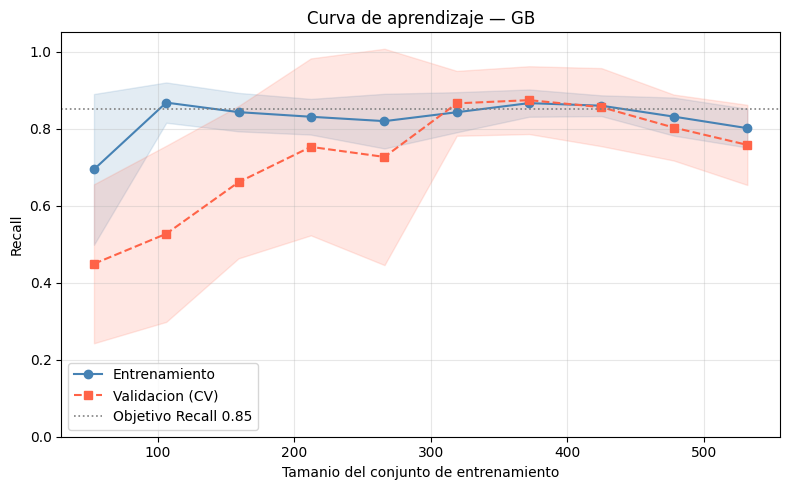

🏃 View run gb_learning_curve_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/3/runs/46da3b8748364012a96357e870f13f1c
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/3
Curva guardada en: C:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivienda\reports\figures\gb\learning_curve.png


In [7]:
bp = {k.removeprefix('clf__'): v for k, v in grid_search.best_params_.items()}

mejor_modelo = make_pipeline(**bp)

train_sizes, train_scores, val_scores = learning_curve(
    mejor_modelo, X, y,
    cv=cv,
    scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

tr_mean = train_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
va_mean = val_scores.mean(axis=1)
va_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Entrenamiento')
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, va_mean, 's--', color='tomato', label='Validacion (CV)')
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std,
                alpha=0.15, color='tomato')
ax.axhline(0.85, color='gray', linestyle=':', linewidth=1.2, label='Objetivo Recall 0.85')
ax.set_xlabel('Tamanio del conjunto de entrenamiento')
ax.set_ylabel('Recall')
ax.set_title(f'Curva de aprendizaje — GB')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
fig.tight_layout()

ruta_lc = r"C:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivienda\reports\figures\gb\learning_curve.png" # change reports\figures\gb\learning_curve.png
fig.savefig(ruta_lc, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='gb_learning_curve_artifact'):
    mlflow.log_artifact(ruta_lc)

print(f'Curva guardada en: {ruta_lc}')

## 7. Matriz de confusion

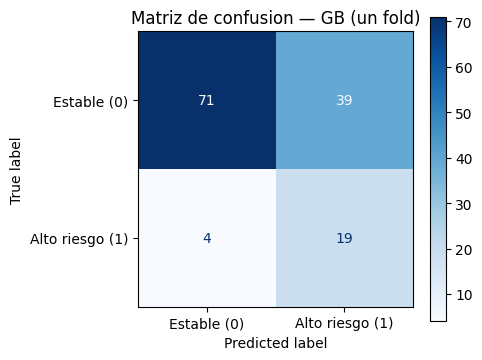

🏃 View run svm_confusion_matrix_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/3/runs/e9d94091699a4ff18b1fb23860d51c26
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/3
Reporte de clasificacion (un fold):
              precision    recall  f1-score   support

     Estable       0.95      0.65      0.77       110
 Alto riesgo       0.33      0.83      0.47        23

    accuracy                           0.68       133
   macro avg       0.64      0.74      0.62       133
weighted avg       0.84      0.68      0.72       133



In [8]:
# Usar el ultimo fold para la visualizacion (consistente con el notebook de logreg)
folds = list(cv.split(X, y))
train_idx, test_idx = folds[-1]

X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

modelo_viz = mejor_modelo
modelo_viz.fit(X_tr, y_tr)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    modelo_viz, X_te, y_te,
    display_labels=['Estable (0)', 'Alto riesgo (1)'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de confusion — GB (un fold)')
fig.tight_layout()

ruta_cm = r'C:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivienda\reports\figures\gb\confusion_matrix.png' #change reports\figures\gb\confusion_matrix.png
fig.savefig(ruta_cm, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='svm_confusion_matrix_artifact'):
    mlflow.log_artifact(ruta_cm)

print('Reporte de clasificacion (un fold):')
print(classification_report(y_te, modelo_viz.predict(X_te),
                             target_names=['Estable', 'Alto riesgo']))

## 8. Importancia de variables (Permutation Importance)

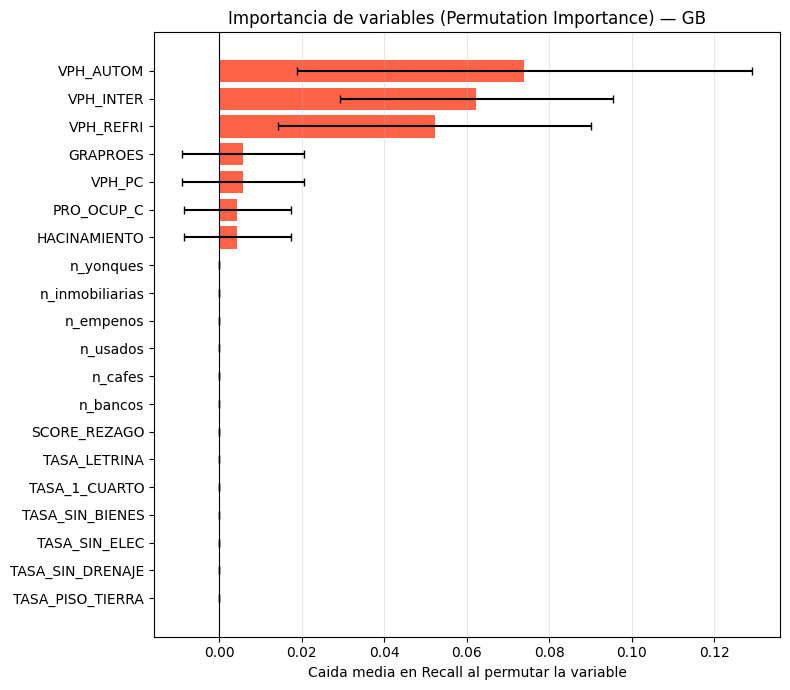

🏃 View run svm_importancia_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/3/runs/f90b2c61b02945a3a93bf83a080486ca
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/3
Top 5 variables mas importantes para el GB:
  feature  importancia_mean  importancia_std
VPH_AUTOM          0.073913         0.055168
VPH_INTER          0.062319         0.033080
VPH_REFRI          0.052174         0.037903
   VPH_PC          0.005797         0.014780
 GRAPROES          0.005797         0.014780


In [9]:
result = permutation_importance(
    modelo_viz, X_te, y_te,
    n_repeats=30,
    random_state=42,
    scoring='recall',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':    X.columns,
    'importancia_mean': result.importances_mean,
    'importancia_std':  result.importances_std
}).sort_values('importancia_mean', ascending=True)

colores = ['tomato' if v > 0 else 'steelblue' for v in perm_df['importancia_mean']]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    perm_df['feature'],
    perm_df['importancia_mean'],
    xerr=perm_df['importancia_std'],
    color=colores,
    capsize=3
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Caida media en Recall al permutar la variable')
ax.set_title('Importancia de variables (Permutation Importance) — GB')
ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()

ruta_imp = r'C:\Users\DELL\Documents\Areas\MCD\2 S\AAA\prediccion-abandono-vivienda\reports\figures\gb\importancia_variables.png' #change reports/figures/gb/importancia_variables.png
fig.savefig(ruta_imp, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='svm_importancia_artifact'):
    mlflow.log_artifact(ruta_imp)

print('Top 5 variables mas importantes para el GB:')
print(
    perm_df.sort_values('importancia_mean', ascending=False)
    .head(5)
    .to_string(index=False)
)

## 9. Comparacion con SVM

# Resultados de referencia de regresion logistica (libreta 5.0)
logreg_referencia = {
    'Modelo': 'Regresion Logistica (L1, C=0.1, balanced)',
    'Recall': 0.7941,
    'F1':     0.4579,
    'AUC':    0.7707
}

# Resultados SVM obtenidos en este notebook
filas = [logreg_referencia]

for run_name, params in runs_a_evaluar.items():
    m_row = tabla_df.loc[run_name]
    kernel = params['kernel']
    C      = params['C']
    cw     = params.get('class_weight', None)
    filas.append({
        'Modelo':  f'SVM ({kernel.upper()}, C={C}, {"balanced" if cw else "sin balanceo"})',
        'Recall':  round(m_row['recall_mean'], 4),
        'F1':      round(m_row['f1_mean'], 4),
        'AUC':     round(m_row['auc_mean'], 4),
    })

comparacion = pd.DataFrame(filas).set_index('Modelo')

# Resaltar si se alcanzo el objetivo
print('=== Comparacion SVM vs Regresion Logistica ===')
print(comparacion.round(4).to_string())
print()
print('Objetivos del proyecto: Recall > 0.85 | F1 > 0.80 | AUC > 0.85')
print()
for modelo, row in comparacion.iterrows():
    alcanza = all([
        row['Recall'] > 0.85,
        row['F1']     > 0.80,
        row['AUC']    > 0.85,
    ])
    estado = 'ALCANZA objetivos' if alcanza else 'NO alcanza objetivos'
    print(f'  {modelo[:45]:<45} -> {estado}')

## 10. Resumen de experimentos registrados en MLflow

In [10]:
experiment = mlflow.get_experiment_by_name('gradientBoosting')

if experiment:
    runs_mlflow = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=''
    )
    cols = [c for c in runs_mlflow.columns
            if c.startswith('metrics.') or c == 'tags.mlflow.runName']
    resumen = runs_mlflow[cols].copy()
    resumen.columns = [
        c.replace('metrics.', '').replace('tags.mlflow.runName', 'run')
        for c in resumen.columns
    ]
    resumen = resumen[resumen['run'].notna()].sort_values('recall_mean', ascending=False)
    print('Runs registrados en MLflow — experimento GB (ordenados por Recall):')
    print(resumen.to_string(index=False))
else:
    print('Experimento no encontrado en MLflow.')

Runs registrados en MLflow — experimento GB (ordenados por Recall):
 f1_mean  auc_mean  auc_std  recall_std  f1_std  recall_mean                           run
  0.3936    0.7274   0.0643      0.1041  0.0561       0.7577    gradientBoosting_best_leaf
  0.4260    0.7388   0.0414      0.0459  0.0336       0.7229   gradientBoosting_best_depth
  0.4061    0.7231   0.0481      0.0923  0.0352       0.6870     gradientBoosting_baseline
  0.4061    0.7231   0.0481      0.0923  0.0352       0.6870     gradientBoosting_baseline
  0.0000    0.7168   0.0557      0.0000  0.0000       0.0000    gradientBoosting_best_leaf
  0.0000    0.7165   0.0560      0.0000  0.0000       0.0000   gradientBoosting_best_depth
  0.0000    0.7168   0.0557      0.0000  0.0000       0.0000    gradientBoosting_best_leaf
  0.0000    0.7165   0.0560      0.0000  0.0000       0.0000   gradientBoosting_best_depth
  0.0000    0.5849   0.0768      0.0000  0.0000       0.0000     gradientBoosting_baseline
  0.0000    0.5849   0

## 11. Conclusiones